In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "Arial.ttf"

# 手动添加字体
font_manager.fontManager.addfont(font_path)

# 设置 matplotlib 使用 Arial
plt.rcParams['font.family'] = 'Arial'





已成功注册 Arial 字体


In [45]:
%matplotlib inline

import os
import numpy as np
import sys
import pickle
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from tqdm import tqdm
from Levenshtein import distance

# import matplotlib.pyplot as plt 
# from matplotlib import font_manager 
 
# # download the font files and save in this fold
# font_path = "/data03/wangkun_data/Arial.ttf"
 
# font_files = font_manager.findSystemFonts(fontpaths=font_path)
 
# for file in font_files:
#     font_manager.fontManager.addfont(file)

In [ ]:
# 需为已执行 poa_novote_only 后的 pkl（含 poa_novote_dis / poa_novote_consensus）
pickle_path = "./model_bench_nanopore.pkl"

with open(pickle_path, "rb") as f:
    ont_ret_dict = pickle.load(f)
print("records:", len(ont_ret_dict))


records: 2000


In [54]:
rows = []
runtime_rows = []

# 内部分析键 -> 写入 stat_df 的 method 列（展示名）
method_to_key = {
    "SeqFormer_noq": "SeqFormer_noq",
    "SeqFormer_qual": "SeqFormer",
    "BSAlign": "BSAlign",
    "BMALA": "BMALA",
    "POA_novote": "Spoa",
    "ITR": "Iterative majority",
}
# 与上键一一对应：output[item] 里取编辑距离的字段名（novote 用 poa_novote_dis）
method_pickle_field = {
    "SeqFormer_noq": "new_dist",
    "SeqFormer_qual": "seqformer_qual_dist",
    "BSAlign": "bs_dis",
    "BMALA": "bmala_dis",
    "POA_novote": "poa_novote_dis",
    "ITR": "itr_dis",
}

for record_idx, (batched_data, output, runtime_data) in enumerate(ont_ret_dict):
    runtime_row = {"record": record_idx}
    runtime_row.update(runtime_data)
    runtime_rows.append(runtime_row)

    for depth_id, item in output.items():
        depth = int(depth_id[1:])
        for internal_key, method_label in method_to_key.items():
            dist_val = item.get(method_pickle_field[internal_key], None)
            if dist_val is None:
                continue
            rows.append(
                {
                    "record": record_idx,
                    "depth": depth,
                    "method": method_label,
                    "distance": dist_val,
                    "exact_match": int(dist_val == 0),
                }
            )

stat_df = pd.DataFrame(rows)
runtime_df = pd.DataFrame(runtime_rows)

# 检查是否已跑过 poa_novote_only（至少一条有 poa_novote_dis）
_has_novote = any(
    "poa_novote_dis" in item
    for _bd, output, _rt in ont_ret_dict[: min(5, len(ont_ret_dict))]
    for item in output.values()
)
if not _has_novote:
    print(
        "警告: pickle 中未找到 poa_novote_dis。请先对 resume_run_dir 执行 "
        "run_mode='poa_novote_only'，或把 pickle_path 指向合并后的 pkl。"
    )
else:
    print("已检测到 poa_novote_dis，使用 Spoa(novote) 曲线。")


已检测到 poa_novote_dis，使用 Spoa(novote) 曲线。


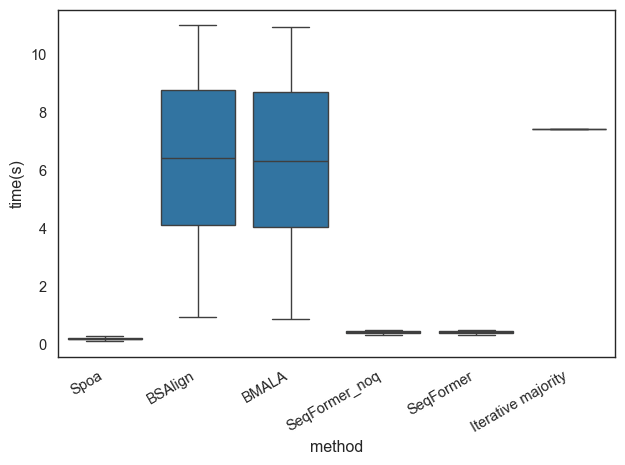

In [55]:
# runtime_df 是宽表，画耗时需 melt（Spoa 对应 poa_novote）
runtime_method_map = {
    "Spoa": "poa_novote",
    "BSAlign": "bs",
    "BMALA": "bmala",
    "SeqFormer_noq": "new_noqual",
    "SeqFormer": "new_qual",
    "Iterative majority": "itr",
}
runtime_plot_rows = []
for row in runtime_rows:
    for method_label, col in runtime_method_map.items():
        if col in row:
            runtime_plot_rows.append(
                {"method": method_label, "time(s)": row[col]}
            )
runtime_plot_df = pd.DataFrame(runtime_plot_rows)

plt.figure()
sns.boxplot(
    data=runtime_plot_df,
    x="method",
    y="time(s)",
    order=list(runtime_method_map.keys()),
    showfliers=False,
)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()


In [56]:
result_df = (
    stat_df.groupby(["method", "depth"])
    .agg(
        cluster_count=("record", "count"),
        zero_distance_count=("exact_match", "sum"),
        sum_distance=("distance", "sum"),
    )
    .reset_index()
)
result_df["success_rate"] = (
    result_df["zero_distance_count"] / result_df["cluster_count"]
)
result_df["mean_distance"] = (
    result_df["sum_distance"] / result_df["cluster_count"]
)
result_df=result_df[result_df['depth'].between(5, 25)]

<Axes: xlabel='depth', ylabel='mean_distance'>

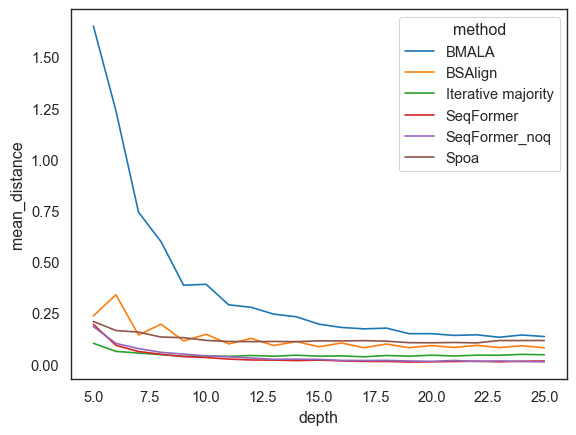

In [57]:
plt.figure()
sns.lineplot(data=result_df, x='depth', y='mean_distance', hue='method')

,method,depth,cluster_count,zero_distance_count,sum_distance,success_rate,mean_distance
2,BMALA,5,2000,1328,3304,0.6640,1.6520
3,BMALA,6,2000,1437,2476,0.7185,1.2380
4,BMALA,7,2000,1627,1487,0.8135,0.7435
5,BMALA,8,2000,1677,1198,0.8385,0.5990
6,BMALA,9,2000,1764,773,0.8820,0.3865
...,...,...,...,...,...,...,...
133,Spoa,21,2000,1901,214,0.9505,0.1070
134,Spoa,22,2000,1905,210,0.9525,0.1050
135,Spoa,23,2000,1891,233,0.9455,0.1165
136,Spoa,24,2000,1891,233,0.9455,0.1165


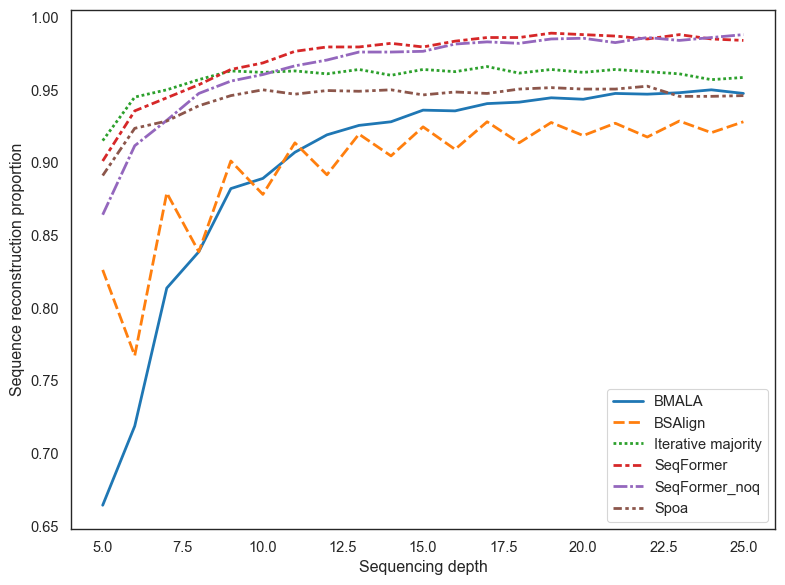

In [58]:
plt.figure(figsize=(8, 6))
sns.set_context("paper", font_scale=1.2)
sns.lineplot(data=result_df, x='depth', y='success_rate', hue='method', style="method", lw=2)
plt.legend(loc='best',)
plt.xlabel('Sequencing depth')
plt.ylabel('Sequence reconstruction proportion')
plt.tight_layout()
plt.savefig('nanopore_reco_bench_v2_second.png', dpi=400)
result_df

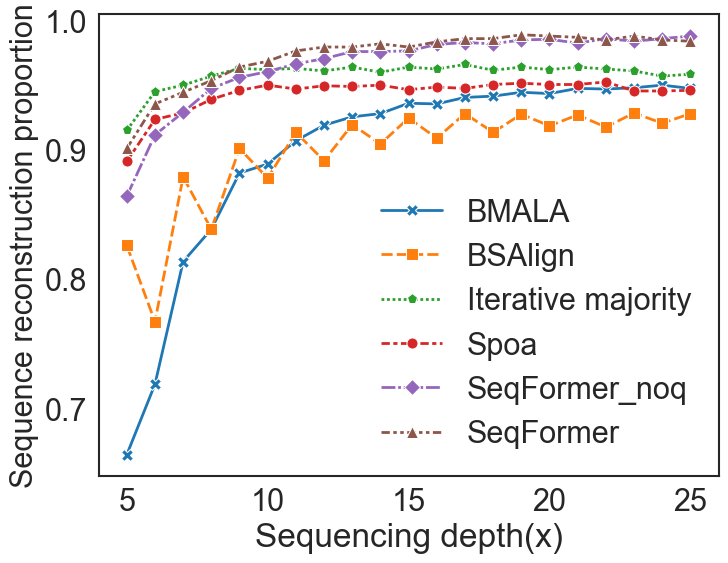

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# =======================================
# 📌 统一字体配置区域（你只需改这里）
# =======================================
XTICK_SIZE   = 22
YTICK_SIZE   = 22
XLABEL_SIZE  = 24
YLABEL_SIZE  = 22
LEGEND_SIZE  = 22
SPINE_WIDTH  = 1.5

sns.set_style("white")

plt.figure(figsize=(8, 6))

order = [
    "BMALA",
    "BSAlign",
    "Iterative majority",
    "Spoa",
    "SeqFormer_noq",
    "SeqFormer",
    
]
custom_colors = {
    "BMALA": "#1f77b4",              # 灰
    "BSAlign": "#ff7f0e",            # 深灰
    "Iterative majority": "#2ca02c", # 浅蓝
    "Spoa": "#d62728",               # 蓝
    "SeqFormer_noq": "#9467bd",   # 绿
    "SeqFormer": "#8c564b",     # 红（重点突出）
}

ax = sns.lineplot(
    x='depth',
    y='success_rate',
    hue="method",
    style="method",
    markers=["X", "s", "p", "o", "D", "^"],
    markersize=8,
    lw=2,
    data=result_df,
    hue_order=order,
    style_order=order,
   palette=custom_colors,
)
# =======================================
# 坐标轴名称
# =======================================
ax.set_xlabel('Sequencing depth(x)', fontsize=XLABEL_SIZE)
ax.set_ylabel('Sequence reconstruction proportion', fontsize=YLABEL_SIZE)

# =======================================
# 坐标轴刻度字体
# =======================================
ax.tick_params(axis='x', labelsize=XTICK_SIZE)
ax.tick_params(axis='y', labelsize=YTICK_SIZE)

# =======================================
# 坐标轴线条加粗
# =======================================
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(SPINE_WIDTH)

# =======================================
# Legend：放到图外右侧（完全独立区域）
# =======================================
legend = ax.legend(
    prop={'size': LEGEND_SIZE},
    loc='best',
    
    frameon=False  # 去掉legend边框（论文常用）
)

# =======================================
# 调整布局，给右侧 legend 留空间
# =======================================

# ,bbox_inches='tight'
plt.savefig("seq_recovery_compare_organick.png", dpi=600,bbox_inches='tight')
plt.show()
